In [2]:
import pandas as pd
import numpy as np
import os

import tensorflow as tf
import matplotlib.pyplot as plt

import albumentations as A

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('PCB_dataset.csv', index_col=0)

In [4]:
df.head(10)

,xmin,ymin,xmax,ymax,name,pose,truncated,difficult,filename
0,374,158,392,174,open_circuit,Unspecified,0,0,../VOC_PCB/JPEGImages/light_06_open_circuit_05...
1,507,341,549,366,spur,Unspecified,0,0,../VOC_PCB/JPEGImages/rotation_90_light_09_spu...
2,198,550,234,571,spur,Unspecified,0,0,../VOC_PCB/JPEGImages/rotation_90_light_09_spu...
3,4,250,40,285,mouse_bite,Unspecified,0,0,../VOC_PCB/JPEGImages/l_light_07_mouse_bite_06...
4,556,75,579,96,open_circuit,Unspecified,0,0,../VOC_PCB/JPEGImages/light_07_open_circuit_10...
5,1,343,23,378,short,Unspecified,0,0,../VOC_PCB/JPEGImages/rotation_270_light_01_sh...
6,12,392,41,414,short,Unspecified,0,0,../VOC_PCB/JPEGImages/rotation_270_light_01_sh...
7,130,53,154,78,mouse_bite,Unspecified,0,0,../VOC_PCB/JPEGImages/l_light_04_mouse_bite_05...
8,328,1,348,23,mouse_bite,Unspecified,0,0,../VOC_PCB/JPEGImages/l_light_04_mouse_bite_05...
9,483,386,521,423,mouse_bite,Unspecified,0,0,../VOC_PCB/JPEGImages/rotation_270_light_10_mo...


In [5]:
df = df.rename(columns={'name':'defect'})
df = df.drop(['truncated','difficult', 'pose'], axis=1)
df.insert(0, 'filename', df.pop('filename'))
#df['defect_orig'] = df['defect']


In [6]:
#df = pd.get_dummies(df, columns = ['defect'], dtype= int)
df


,filename,xmin,ymin,xmax,ymax,defect
0,../VOC_PCB/JPEGImages/light_06_open_circuit_05...,374,158,392,174,open_circuit
1,../VOC_PCB/JPEGImages/rotation_90_light_09_spu...,507,341,549,366,spur
2,../VOC_PCB/JPEGImages/rotation_90_light_09_spu...,198,550,234,571,spur
3,../VOC_PCB/JPEGImages/l_light_07_mouse_bite_06...,4,250,40,285,mouse_bite
4,../VOC_PCB/JPEGImages/light_07_open_circuit_10...,556,75,579,96,open_circuit
...,...,...,...,...,...,...
21659,../VOC_PCB/JPEGImages/rotation_270_light_08_sh...,315,197,347,236,short
21660,../VOC_PCB/JPEGImages/rotation_270_light_08_sh...,63,282,101,322,short
21661,../VOC_PCB/JPEGImages/light_09_mouse_bite_10_2...,265,116,291,144,mouse_bite
21662,../VOC_PCB/JPEGImages/rotation_270_light_07_sp...,521,172,546,212,spur


In [6]:
df.to_csv('PCB_dataset_clean.csv')

some test images:

In [7]:
def show_bbox(filename):
    im = plt.imread(filename)
    plt.imshow(im)
    bbox_list = []
    for k in range(len(df)):
        if df.filename[k] == filename:
            bbox_list.append([df.iloc[k,1], df.iloc[k,2], df.iloc[k,3], df.iloc[k,4], df.iloc[k,5]])

    for i in range(len(bbox_list)):
        x_min = bbox_list[i][0]
        y_min = bbox_list[i][1]
        x_max = bbox_list[i][2]
        y_max = bbox_list[i][3]
        plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], '-r')
        plt.text(x_min, y_min, bbox_list[i][4], color='red')

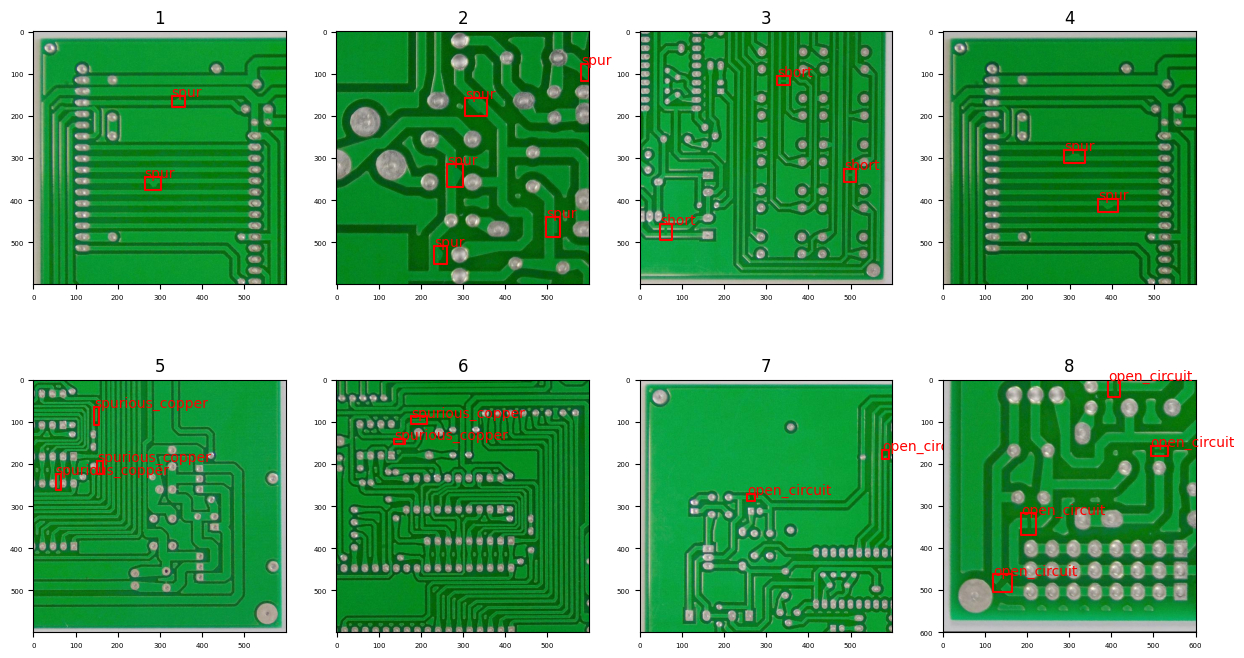

In [8]:
plt.figure(figsize=(15,8))
plt.subplots_adjust(hspace=0.3)
j=1

for i in np.random.randint(0, len(df), size=[8]):
    ax = plt.subplot(2,4,j)
    ax.tick_params(labelsize = 5)
    show_bbox(df.filename[i])
    plt.title(j)
    

    j+=1

DATA AUGMENTATION:

examples:

In [9]:
transform_list = [
    A.RandomBrightnessContrast(brightness_limit=(-0.2, 0.2), p=1),
    A.RandomCrop(p=1,height = 512, width = 512),
    A.Rotate(p=1, limit=90),
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.HueSaturationValue(p=1,hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=50),
    A.RandomSunFlare(p=1)
]

def transform_standard(filename, transform):
    transforming = A.Compose([transform], bbox_params=A.BboxParams(format='pascal_voc'))
    im = plt.imread(filename)
    bbox_list = []
    for k in range(len(df)):
        if df.filename[k] == filename:
            bbox_list.append([df.iloc[k,1], df.iloc[k,2], df.iloc[k,3], df.iloc[k,4], df.iloc[k,5]])
    transformed = transforming(image=im, bboxes = bbox_list)
    return transformed




Shows a random image and one of its possible transformations:

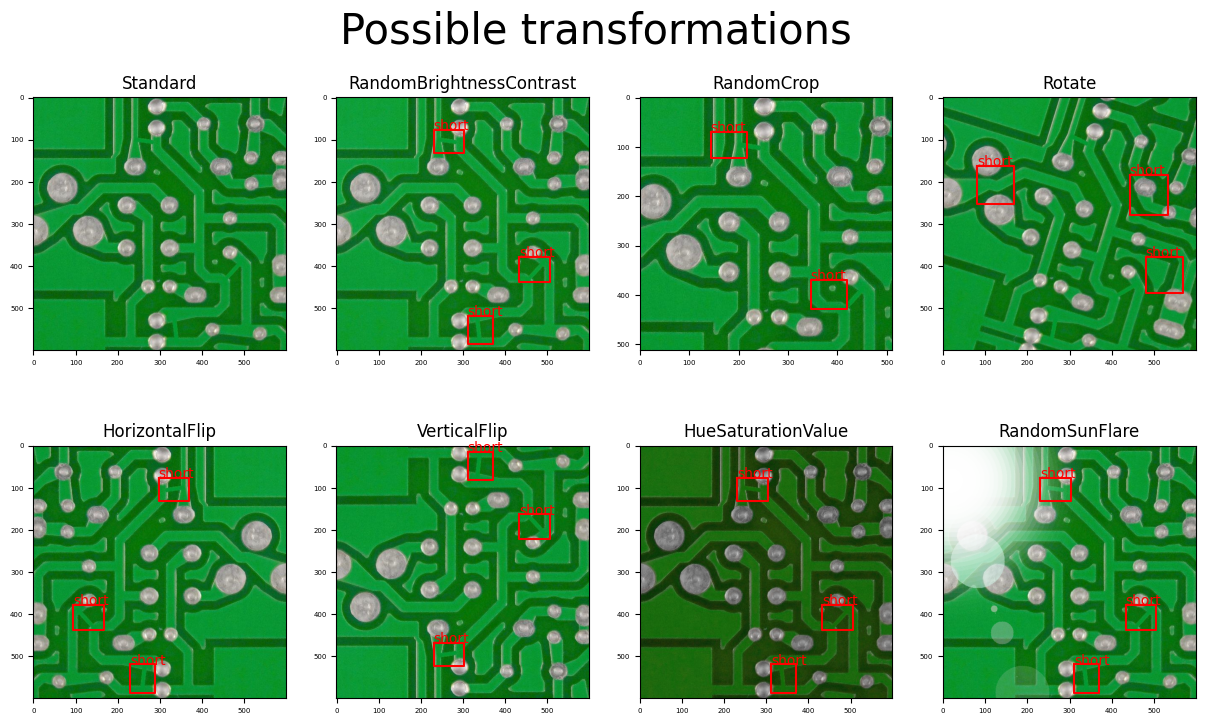

In [10]:
j = np.random.randint(0, len(df))

plt.figure(figsize=(15,8))
plt.suptitle("Possible transformations", fontsize = 30)
plt.subplots_adjust(hspace=0.3)

ax1 = plt.subplot(2,4,1)
ax1.tick_params(labelsize = 5)
im =  plt.imread(df.filename[j])
plt.imshow(im)
plt.title("Standard")

for i, transf in enumerate(transform_list):
    ax = plt.subplot(2,4,i+2)
    ax.tick_params(labelsize = 5)
    trans_im = transform_standard(df.filename[j], transf)['image']
    plt.imshow(trans_im)
    trans_bbox  = transform_standard(df.filename[j], transf)['bboxes']
    for i in range(len(trans_bbox)):
        x_min = trans_bbox[i][0]
        y_min = trans_bbox[i][1]
        x_max = trans_bbox[i][2]
        y_max = trans_bbox[i][3]
        plt.plot([x_min, x_max, x_max, x_min, x_min], [y_min, y_min, y_max, y_max, y_min], '-r')
        plt.text(x_min, y_min, trans_bbox[i][4], color='red')
        plt.title(transf.__class__.__name__)

plt.show()



Transforming Images with a composition of augmentations:

In [11]:
def augmentation(filename, bbox):
    transform =  A.Compose([
                            A.VerticalFlip(p=0.2),
                            #A.RandomSunFlare(p=0.2),
                            A.RandomFog(p=0.2),
                            A.RandomGamma(p=0.2),
                            #A.RandomCrop(p=0.2,height = 512, width = 512),
                            #A.Rotate(p=0.2, limit=90),
                            A.RGBShift(p=0.2),
                            A.HorizontalFlip(p=0.2),
                            A.RandomBrightnessContrast(brightness_limit = 0.3),
                            A.HueSaturationValue(p=0.2,hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=50)
                            ], bbox_params=A.BboxParams(format='pascal_voc'))
    im = plt.imread(filename)
    transformed = transform(image=im, bboxes = [bbox])
    return transformed

In [30]:
row = 5

In [32]:
os.path.splitext(os.path.basename(df.filename[0]))[0] + "-" + str(row)



'light_06_open_circuit_05_1_600-5'

In [36]:
'augmented/'+ os.path.splitext(os.path.basename(df.filename[row].split('/')[-1]))[0] + "-" + str(row) + ".jpg"

'augmented/light_06_open_circuit_05_1_600-0jpg'

In [41]:
'augmented/'+ os.path.splitext(os.path.basename(df.filename[row].split('/')[-1]))[0] + "-" + str(row) + ".jpg"

'augmented/rotation_270_light_07_spur_02_4_600-21663.jpg'

In [42]:
rows = []
  
for row in range(len(df)):
	diction = {}
	keys = ['filename','xmin', 'ymin', 'xmax', 'ymax', 'defect']
	values, = augmentation(df.filename[row], df.iloc[row,1:6].tolist())['bboxes']
	values = ['./augmented/'+ os.path.splitext(os.path.basename(df.filename[row].split('/')[-1]))[0] + "-" + str(row) + ".jpg", values[0], values[1], values[2], values[3], values[4]]
	diction = dict(zip(keys, values))
	rows.append(diction)

	plt.imsave('augmented/'+ os.path.splitext(os.path.basename(df.filename[row].split('/')[-1]))[0] + "-" + str(row) + ".jpg", augmentation(df.filename[row], df.iloc[row,1:6].tolist())['image'])

df2 = pd.DataFrame(rows, columns = ['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'defect'])


In [43]:
df2.head()
#df2.shape


,filename,xmin,ymin,xmax,ymax,defect
0,./augmented/light_06_open_circuit_05_1_600-0.jpg,374.0,158.0,392.0,174.0,open_circuit
1,./augmented/rotation_90_light_09_spur_02_3_600...,507.0,341.0,549.0,366.0,spur
2,./augmented/rotation_90_light_09_spur_02_3_600...,198.0,550.0,234.0,571.0,spur
3,./augmented/l_light_07_mouse_bite_06_4_600-3.jpg,4.0,250.0,40.0,285.0,mouse_bite
4,./augmented/light_07_open_circuit_10_2_600-4.jpg,556.0,75.0,579.0,96.0,open_circuit


saving preprocessed dataset:

In [44]:
df2.to_csv("./augmented/PCB_dataset_augmented.csv")